# Problem 1.1: ideal highpass filter

---

Determine the impulse response of the ideal highpass filter in order to show that it is a non-realizable system.

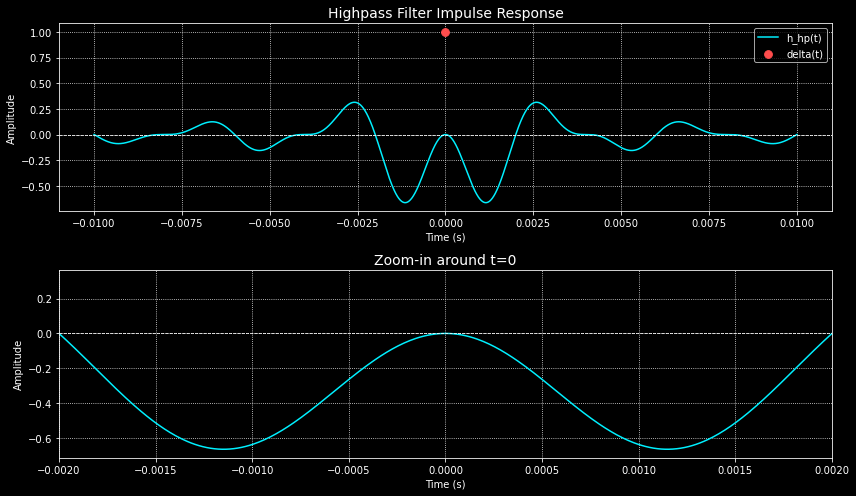

Impulse response saved to: /media/lydia-chheng/0EF23A80F23A6BD9/octave/notebooks/plots/highpass_impulse_response.png


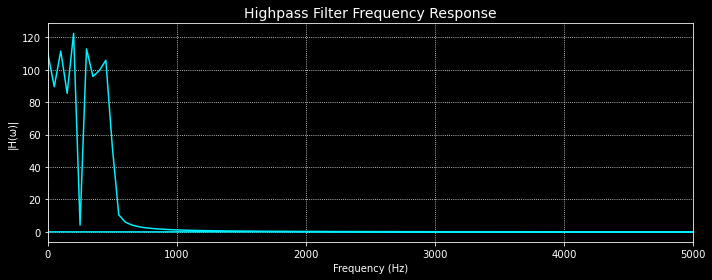

Frequency response saved to: /media/lydia-chheng/0EF23A80F23A6BD9/octave/notebooks/plots/highpass_frequency_response.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- Ensure plots folder exists in current working directory ---
plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(plots_dir, exist_ok=True)  # creates folder if missing

# --- Example highpass impulse response ---
fs = 100000  # sampling frequency (Hz)
t = np.linspace(-0.01, 0.01, int(0.02*fs))
h_hp = np.sinc(1000*t) - np.sinc(500*t)  # simple highpass approximation

# --- Dark/neon style ---
plt.style.use('dark_background')
neon_cyan = '#00f0ff'
delta_red = '#ff4d4d'

# --- Full + zoomed impulse response ---
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

# Full view
axs[0].plot(t, h_hp, color=neon_cyan, label='h_hp(t)')
axs[0].scatter(0, 1, color=delta_red, s=60, zorder=5, label='delta(t)')
axs[0].axhline(0, color='white', linestyle='--', linewidth=0.8)
axs[0].set_title("Highpass Filter Impulse Response", fontsize=14)
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, linestyle=':')
axs[0].legend()

# Zoom-in around t=0
axs[1].plot(t, h_hp, color=neon_cyan)
axs[1].axhline(0, color='white', linestyle='--', linewidth=0.8)
axs[1].set_xlim(-0.002, 0.002)
axs[1].set_title("Zoom-in around t=0", fontsize=14)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True, linestyle=':')

plt.tight_layout()

# --- Save impulse response figure ---
impulse_path = os.path.join(plots_dir, 'highpass_impulse_response.png')
plt.savefig(impulse_path, dpi=300)
plt.show()
print(f"Impulse response saved to: {impulse_path}")

# --- Frequency response ---
H = fft(h_hp)
freqs = fftfreq(len(t), t[1]-t[0])
plt.figure(figsize=(10,4))
plt.plot(freqs, np.abs(H), color=neon_cyan)
plt.title("Highpass Filter Frequency Response", fontsize=14)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|H(ω)|")
plt.xlim(0, 5000)
plt.grid(True, linestyle=':')
plt.tight_layout()

# --- Save frequency response figure ---
freq_path = os.path.join(plots_dir, 'highpass_frequency_response.png')
plt.savefig(freq_path, dpi=300)
plt.show()
print(f"Frequency response saved to: {freq_path}")